<a href="https://colab.research.google.com/github/thaovu31251021311-star/AI_Homework_2/blob/main/BT_2_11_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 16.6 MB/s eta 0:00:00


Giá dự đoán: 91.1904761904762
Điểm thưởng: 88.33333333333333


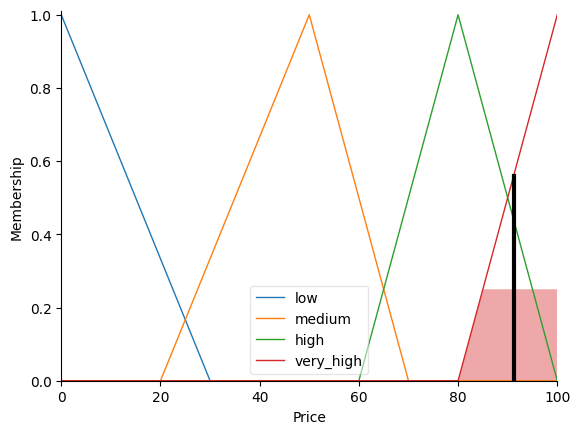

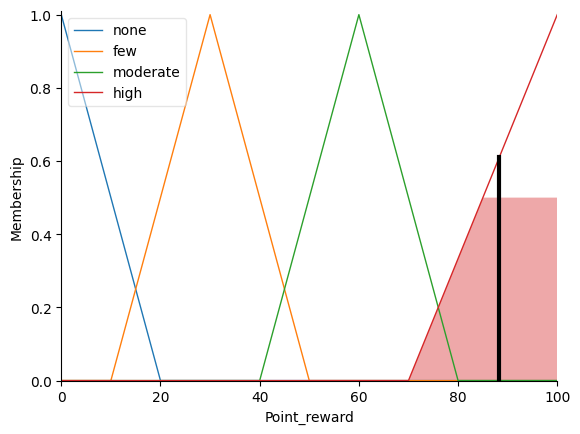

In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

Ride_distance = ctrl.Antecedent(np.arange(0, 50.1, 1), 'Ride_distance')
Traffic_condition = ctrl.Antecedent(np.arange(0, 100.1, 1), 'Traffic_condition')
Demand_level = ctrl.Antecedent(np.arange(0, 100.1, 1), 'Demand_level')
Weather_condition = ctrl.Antecedent(np.arange(0, 10.1, 1), 'Weather_condition')
Customer_rating = ctrl.Antecedent(np.arange(1, 5.1, 1), 'Customer_rating')
Ride_punctuality = ctrl.Antecedent(np.arange(0, 100.1, 1), 'Ride_punctuality')

Price = ctrl.Consequent(np.arange(0, 100.1, 1), 'Price')
Point_reward = ctrl.Consequent(np.arange(0, 100.1, 1), 'Point_reward')

Ride_distance['short'] = fuzz.trimf(Ride_distance.universe, [0, 0, 3])
Ride_distance['medium'] = fuzz.trimf(Ride_distance.universe, [2, 5, 8])
Ride_distance['long'] = fuzz.trimf(Ride_distance.universe, [6, 13, 20])
Ride_distance['very_long'] = fuzz.trimf(Ride_distance.universe, [15, 30, 50])

Traffic_condition['low'] = fuzz.trimf(Traffic_condition.universe, [0, 0, 30])
Traffic_condition['medium'] = fuzz.trimf(Traffic_condition.universe, [20, 50, 70])
Traffic_condition['high'] = fuzz.trimf(Traffic_condition.universe, [60, 100, 100])

Demand_level['low'] = fuzz.trimf(Demand_level.universe, [0, 0, 30])
Demand_level['medium'] = fuzz.trimf(Demand_level.universe, [20, 50, 70])
Demand_level['high'] = fuzz.trimf(Demand_level.universe, [60, 100, 100])

Weather_condition['good'] = fuzz.trimf(Weather_condition.universe, [0, 0, 3])
Weather_condition['moderate'] = fuzz.trimf(Weather_condition.universe, [2, 5, 7])
Weather_condition['bad'] = fuzz.trimf(Weather_condition.universe, [6, 10, 10])

Customer_rating['poor'] = fuzz.trimf(Customer_rating.universe, [1, 1, 2])
Customer_rating['average'] = fuzz.trimf(Customer_rating.universe, [2, 3, 4])
Customer_rating['good'] = fuzz.trimf(Customer_rating.universe, [4, 5, 5])

Ride_punctuality['late'] = fuzz.trimf(Ride_punctuality.universe, [0, 0, 50])
Ride_punctuality['ontime'] = fuzz.trimf(Ride_punctuality.universe, [40, 60, 80])
Ride_punctuality['early'] = fuzz.trimf(Ride_punctuality.universe, [70, 100, 100])

Price['low'] = fuzz.trimf(Price.universe, [0, 0, 30])
Price['medium'] = fuzz.trimf(Price.universe, [20, 50, 70])
Price['high'] = fuzz.trimf(Price.universe, [60, 80, 100])
Price['very_high'] = fuzz.trimf(Price.universe, [80, 100, 100])

Point_reward['none'] = fuzz.trimf(Point_reward.universe, [0, 0, 20])
Point_reward['few'] = fuzz.trimf(Point_reward.universe, [10, 30, 50])
Point_reward['moderate'] = fuzz.trimf(Point_reward.universe, [40, 60, 80])
Point_reward['high'] = fuzz.trimf(Point_reward.universe, [70, 100, 100])

rules = [
    ctrl.Rule(Ride_distance['short'] & Traffic_condition['low'] & Demand_level['low'], Price['low']),
    ctrl.Rule(Ride_distance['short'] & Traffic_condition['medium'] & Demand_level['high'], Price['medium']),
    ctrl.Rule(Ride_distance['medium'] & Traffic_condition['high'] & Demand_level['high'], Price['high']),
    ctrl.Rule(Ride_distance['long'] & Traffic_condition['medium'] & Weather_condition['good'], Price['medium']),
    ctrl.Rule(Ride_distance['long'] & Traffic_condition['high'] & Weather_condition['bad'], Price['very_high']),
    ctrl.Rule(Ride_distance['very_long'] & Traffic_condition['high'] & Demand_level['high'], Price['very_high']),
    ctrl.Rule(Ride_distance['medium'] & Traffic_condition['low'] & Demand_level['low'], Price['medium']),
    ctrl.Rule(Ride_distance['short'] & Traffic_condition['high'] & Weather_condition['bad'], Price['high']),
    ctrl.Rule(Ride_distance['very_long'] & Weather_condition['bad'], Price['very_high']),
    ctrl.Rule(Ride_distance['medium'] & Traffic_condition['medium'] & Weather_condition['moderate'], Price['medium']),

    ctrl.Rule(Customer_rating['good'] & Ride_punctuality['early'], Point_reward['high']),
    ctrl.Rule(Customer_rating['average'] & Ride_punctuality['ontime'], Point_reward['moderate']),
    ctrl.Rule(Customer_rating['poor'] & Ride_punctuality['late'], Point_reward['none']),
    ctrl.Rule(Ride_distance['long'] & Traffic_condition['high'] & Ride_punctuality['ontime'], Point_reward['high']),
    ctrl.Rule(Ride_distance['medium'] & Traffic_condition['medium'] & Customer_rating['good'], Point_reward['moderate']),
    ctrl.Rule(Customer_rating['poor'] & Ride_punctuality['late'], Point_reward['none']),
    ctrl.Rule(Ride_distance['very_long'] & Weather_condition['bad'] & Customer_rating['good'], Point_reward['high']),
    ctrl.Rule(Ride_distance['short'] & Customer_rating['average'] & Ride_punctuality['ontime'], Point_reward['few']),
    ctrl.Rule(Ride_distance['long'] & Traffic_condition['high'] & Ride_punctuality['late'], Point_reward['few']),
    ctrl.Rule(Ride_distance['medium'] & Weather_condition['moderate'] & Customer_rating['good'], Point_reward['moderate']),
]

system = ctrl.ControlSystem(rules)
sim = ctrl.ControlSystemSimulation(system)

sim.input['Ride_distance'] = 10
sim.input['Traffic_condition'] = 80
sim.input['Demand_level'] = 75
sim.input['Weather_condition'] = 7
sim.input['Customer_rating'] = 4.5
sim.input['Ride_punctuality'] = 60

sim.compute()

print("Giá dự đoán:", sim.output['Price'])
print("Điểm thưởng:", sim.output['Point_reward'])

Price.view(sim=sim)
Point_reward.view(sim=sim)

Mức giảm giá đề xuất (%): 59.5


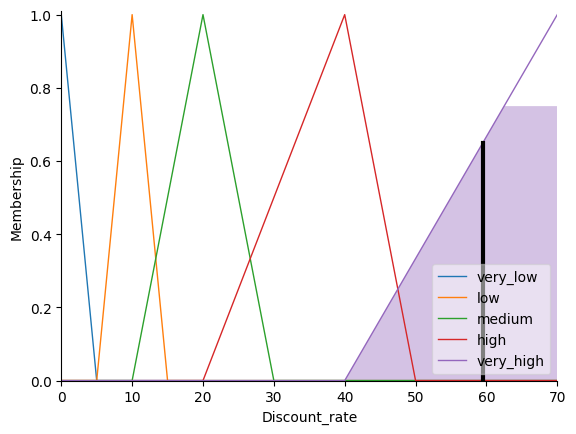

In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

Store_rating = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'Store_rating')
Sales_volume = ctrl.Antecedent(np.arange(0, 101, 1), 'Sales_volume')
Profit_margin = ctrl.Antecedent(np.arange(0, 101, 1), 'Profit_margin')
Seasonal_event = ctrl.Antecedent(np.arange(0, 101, 1), 'Seasonal_event')
Competitor_Discounts = ctrl.Antecedent(np.arange(0, 101, 1), 'Competitor_Discounts')

Discount_rate = ctrl.Consequent(np.arange(0, 71, 1), 'Discount_rate')

Store_rating['low'] = fuzz.trimf(Store_rating.universe, [0, 0, 4])
Store_rating['medium'] = fuzz.trimf(Store_rating.universe, [4, 4.25, 4.5])
Store_rating['high'] = fuzz.trimf(Store_rating.universe, [4.5, 5, 5])

Sales_volume['low'] = fuzz.trimf(Sales_volume.universe, [0, 0, 40])
Sales_volume['medium'] = fuzz.trimf(Sales_volume.universe, [30, 50, 70])
Sales_volume['high'] = fuzz.trimf(Sales_volume.universe, [60, 100, 100])

Profit_margin['low'] = fuzz.trimf(Profit_margin.universe, [0, 0, 30])
Profit_margin['medium'] = fuzz.trimf(Profit_margin.universe, [20, 50, 70])
Profit_margin['high'] = fuzz.trimf(Profit_margin.universe, [60, 100, 100])

Seasonal_event['none'] = fuzz.trimf(Seasonal_event.universe, [0, 0, 20])
Seasonal_event['medium'] = fuzz.trimf(Seasonal_event.universe, [20, 50, 70])
Seasonal_event['high'] = fuzz.trimf(Seasonal_event.universe, [60, 100, 100])

Competitor_Discounts['low'] = fuzz.trimf(Competitor_Discounts.universe, [0, 0, 30])
Competitor_Discounts['medium'] = fuzz.trimf(Competitor_Discounts.universe, [20, 50, 70])
Competitor_Discounts['high'] = fuzz.trimf(Competitor_Discounts.universe, [60, 100, 100])

Discount_rate['very_low'] = fuzz.trimf(Discount_rate.universe, [0, 0, 5])
Discount_rate['low'] = fuzz.trimf(Discount_rate.universe, [5, 10, 15])
Discount_rate['medium'] = fuzz.trimf(Discount_rate.universe, [10, 20, 30])
Discount_rate['high'] = fuzz.trimf(Discount_rate.universe, [20, 40, 50])
Discount_rate['very_high'] = fuzz.trimf(Discount_rate.universe, [40, 70, 70])

rules = [
    ctrl.Rule(Store_rating['high'] & Sales_volume['high'] & Profit_margin['high'], Discount_rate['very_low']),
    ctrl.Rule(Store_rating['low'] & Sales_volume['low'] & Profit_margin['high'], Discount_rate['high']),
    ctrl.Rule(Seasonal_event['high'] & Competitor_Discounts['high'], Discount_rate['very_high']),
    ctrl.Rule(Store_rating['medium'] & Sales_volume['medium'] & Profit_margin['medium'], Discount_rate['medium']),
    ctrl.Rule(Competitor_Discounts['low'] & Profit_margin['low'] & Sales_volume['high'], Discount_rate['very_low']),
    ctrl.Rule(Store_rating['low'] & Seasonal_event['none'], Discount_rate['medium']),
    ctrl.Rule(Sales_volume['low'] & Profit_margin['low'], Discount_rate['very_high']),
]

system = ctrl.ControlSystem(rules)
sim = ctrl.ControlSystemSimulation(system)

sim.input['Store_rating'] = 4.3
sim.input['Sales_volume'] = 50
sim.input['Profit_margin'] = 20
sim.input['Seasonal_event'] = 90
sim.input['Competitor_Discounts'] = 90

sim.compute()

print("Mức giảm giá đề xuất (%):", sim.output['Discount_rate'])

Discount_rate.view(sim=sim)

Mức giảm giá đề xuất (%): 20.0


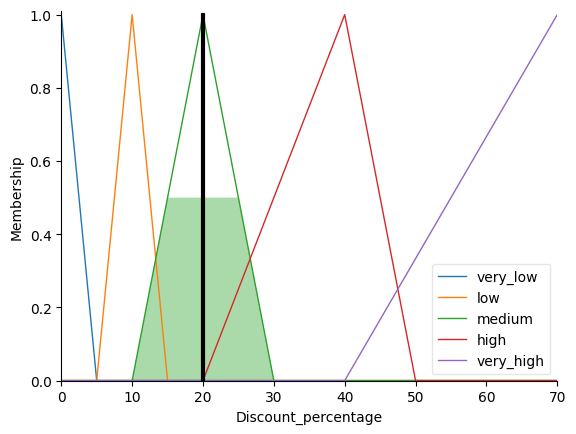

In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

Product_demand = ctrl.Antecedent(np.arange(0, 101, 1), 'Product_demand')
Competitor_pricing_pressure = ctrl.Antecedent(np.arange(0, 101, 1), 'Competitor_pricing_pressure')
Store_reputation = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'Store_reputation')
Profit_margin = ctrl.Antecedent(np.arange(0, 101, 1), 'Profit_margin')
Seasonal_demand = ctrl.Antecedent(np.arange(0, 101, 1), 'Seasonal_demand')

Discount_percentage = ctrl.Consequent(np.arange(0, 71, 1), 'Discount_percentage')

Product_demand['low'] = fuzz.trimf(Product_demand.universe, [0, 0, 40])
Product_demand['medium'] = fuzz.trimf(Product_demand.universe, [30, 50, 70])
Product_demand['high'] = fuzz.trimf(Product_demand.universe, [60, 100, 100])

Competitor_pricing_pressure['low'] = fuzz.trimf(Competitor_pricing_pressure.universe, [0, 0, 30])
Competitor_pricing_pressure['medium'] = fuzz.trimf(Competitor_pricing_pressure.universe, [30, 50, 70])
Competitor_pricing_pressure['high'] = fuzz.trimf(Competitor_pricing_pressure.universe, [60, 100, 100])

Store_reputation['low'] = fuzz.trimf(Store_reputation.universe, [0, 0, 4])
Store_reputation['medium'] = fuzz.trimf(Store_reputation.universe, [4, 4.25, 4.5])
Store_reputation['high'] = fuzz.trimf(Store_reputation.universe, [4.5, 5, 5])

Profit_margin['low'] = fuzz.trimf(Profit_margin.universe, [0, 0, 30])
Profit_margin['medium'] = fuzz.trimf(Profit_margin.universe, [20, 50, 70])
Profit_margin['high'] = fuzz.trimf(Profit_margin.universe, [60, 100, 100])

Seasonal_demand['none'] = fuzz.trimf(Seasonal_demand.universe, [0, 0, 20])
Seasonal_demand['medium'] = fuzz.trimf(Seasonal_demand.universe, [20, 50, 70])
Seasonal_demand['high'] = fuzz.trimf(Seasonal_demand.universe, [60, 100, 100])

Discount_percentage['very_low'] = fuzz.trimf(Discount_percentage.universe, [0, 0, 5])
Discount_percentage['low'] = fuzz.trimf(Discount_percentage.universe, [5, 10, 15])
Discount_percentage['medium'] = fuzz.trimf(Discount_percentage.universe, [10, 20, 30])
Discount_percentage['high'] = fuzz.trimf(Discount_percentage.universe, [20, 40, 50])
Discount_percentage['very_high'] = fuzz.trimf(Discount_percentage.universe, [40, 70, 70])

rules = [
    ctrl.Rule(Product_demand['high'] & Competitor_pricing_pressure['low'] & Profit_margin['low'], Discount_percentage['very_low']),
    ctrl.Rule(Product_demand['low'] & Competitor_pricing_pressure['high'] & Profit_margin['high'], Discount_percentage['high']),
    ctrl.Rule(Store_reputation['high'] & Profit_margin['medium'] & Seasonal_demand['high'], Discount_percentage['medium']),
    ctrl.Rule(Competitor_pricing_pressure['high'] & Seasonal_demand['high'] & Profit_margin['high'], Discount_percentage['very_high']),
    ctrl.Rule(Store_reputation['low'] & Product_demand['medium'] & Profit_margin['low'], Discount_percentage['medium']),
    ctrl.Rule(Product_demand['high'] & Seasonal_demand['none'] & Competitor_pricing_pressure['low'], Discount_percentage['very_low']),
    ctrl.Rule(Profit_margin['high'] & Competitor_pricing_pressure['medium'] & Seasonal_demand['medium'], Discount_percentage['medium']),
]

system = ctrl.ControlSystem(rules)
sim = ctrl.ControlSystemSimulation(system)

sim.input['Product_demand'] = 90
sim.input['Competitor_pricing_pressure'] = 50
sim.input['Store_reputation'] = 4.2
sim.input['Profit_margin'] = 80
sim.input['Seasonal_demand'] = 50

sim.compute()

print("Mức giảm giá đề xuất (%):", sim.output['Discount_percentage'])

Discount_percentage.view(sim=sim)

Số đơn nên gộp: 8.444444444444445


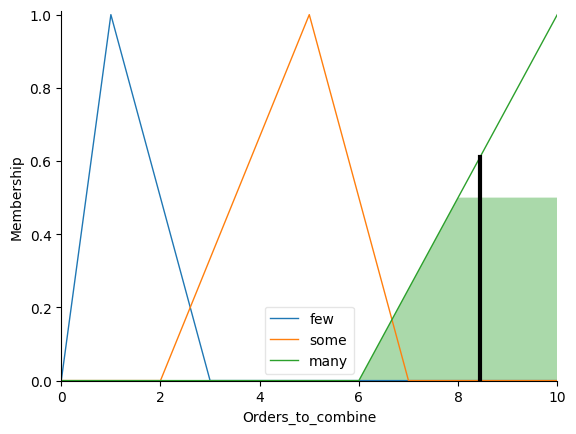

In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

Order_density = ctrl.Antecedent(np.arange(0, 101, 1), 'Order_density')
Delivery_urgency = ctrl.Antecedent(np.arange(0, 101, 1), 'Delivery_urgency')
Driver_current_load = ctrl.Antecedent(np.arange(0, 101, 1), 'Driver_current_load')
Traffic_condition = ctrl.Antecedent(np.arange(0, 101, 1), 'Traffic_condition')
Profit_delivery = ctrl.Antecedent(np.arange(0, 101, 1), 'Profit_delivery')

Orders_to_combine = ctrl.Consequent(np.arange(0, 11, 1), 'Orders_to_combine')
Delivery_priority = ctrl.Consequent(np.arange(0, 101, 1), 'Delivery_priority')

Order_density['low'] = fuzz.trimf(Order_density.universe, [0, 0, 40])
Order_density['medium'] = fuzz.trimf(Order_density.universe, [30, 50, 70])
Order_density['high'] = fuzz.trimf(Order_density.universe, [60, 100, 100])

Delivery_urgency['low'] = fuzz.trimf(Delivery_urgency.universe, [0, 0, 40])
Delivery_urgency['medium'] = fuzz.trimf(Delivery_urgency.universe, [30, 50, 70])
Delivery_urgency['high'] = fuzz.trimf(Delivery_urgency.universe, [60, 100, 100])

Driver_current_load['low'] = fuzz.trimf(Driver_current_load.universe, [0, 0, 40])
Driver_current_load['medium'] = fuzz.trimf(Driver_current_load.universe, [30, 50, 70])
Driver_current_load['high'] = fuzz.trimf(Driver_current_load.universe, [60, 100, 100])

Traffic_condition['low'] = fuzz.trimf(Traffic_condition.universe, [0, 0, 40])
Traffic_condition['medium'] = fuzz.trimf(Traffic_condition.universe, [30, 50, 70])
Traffic_condition['high'] = fuzz.trimf(Traffic_condition.universe, [60, 100, 100])

Profit_delivery['low'] = fuzz.trimf(Profit_delivery.universe, [0, 0, 40])
Profit_delivery['medium'] = fuzz.trimf(Profit_delivery.universe, [30, 50, 70])
Profit_delivery['high'] = fuzz.trimf(Profit_delivery.universe, [60, 100, 100])

Orders_to_combine['few'] = fuzz.trimf(Orders_to_combine.universe, [0, 1, 3])
Orders_to_combine['some'] = fuzz.trimf(Orders_to_combine.universe, [2, 5, 7])
Orders_to_combine['many'] = fuzz.trimf(Orders_to_combine.universe, [6, 10, 10])

Delivery_priority['low'] = fuzz.trimf(Delivery_priority.universe, [0, 0, 40])
Delivery_priority['medium'] = fuzz.trimf(Delivery_priority.universe, [30, 50, 70])
Delivery_priority['high'] = fuzz.trimf(Delivery_priority.universe, [60, 100, 100])

rules = [
    ctrl.Rule(Order_density['high'] & Driver_current_load['low'] & Traffic_condition['low'], Orders_to_combine['many']),
    ctrl.Rule(Order_density['medium'] & Traffic_condition['high'] & Delivery_urgency['medium'], Orders_to_combine['some']),
    ctrl.Rule(Driver_current_load['high'] & Order_density['high'] & Profit_delivery['medium'], Orders_to_combine['some']),
    ctrl.Rule(Order_density['low'] & Delivery_urgency['high'] & Traffic_condition['medium'], Orders_to_combine['some']),
    ctrl.Rule(Profit_delivery['high'] & Delivery_urgency['high'] & Traffic_condition['high'], Orders_to_combine['some']),
    ctrl.Rule(Delivery_urgency['high'] & Profit_delivery['high'], Delivery_priority['high']),
    ctrl.Rule(Delivery_urgency['medium'] & Traffic_condition['medium'], Delivery_priority['medium']),
    ctrl.Rule(Delivery_urgency['low'] & Order_density['high'] & Profit_delivery['low'], Delivery_priority['low']),
]

system = ctrl.ControlSystem(rules)
sim = ctrl.ControlSystemSimulation(system)

sim.input['Order_density'] = 90
sim.input['Delivery_urgency'] = 55
sim.input['Driver_current_load'] = 20
sim.input['Traffic_condition'] = 20
sim.input['Profit_delivery'] = 50

sim.compute()

print("Số đơn nên gộp:", sim.output['Orders_to_combine'])

Orders_to_combine.view(sim=sim)

Mức ưu tiên giao: 49.99999999999999


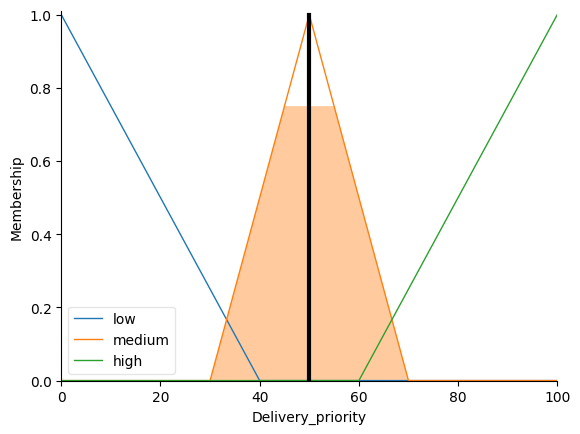

In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

Order_density = ctrl.Antecedent(np.arange(0, 101, 1), 'Order_density')
Delivery_urgency = ctrl.Antecedent(np.arange(0, 101, 1), 'Delivery_urgency')
Driver_current_load = ctrl.Antecedent(np.arange(0, 101, 1), 'Driver_current_load')
Traffic_condition = ctrl.Antecedent(np.arange(0, 101, 1), 'Traffic_condition')
Profit_delivery = ctrl.Antecedent(np.arange(0, 101, 1), 'Profit_delivery')

Orders_to_combine = ctrl.Consequent(np.arange(0, 11, 1), 'Orders_to_combine')
Delivery_priority = ctrl.Consequent(np.arange(0, 101, 1), 'Delivery_priority')

Order_density['low'] = fuzz.trimf(Order_density.universe, [0, 0, 40])
Order_density['medium'] = fuzz.trimf(Order_density.universe, [30, 50, 70])
Order_density['high'] = fuzz.trimf(Order_density.universe, [60, 100, 100])

Delivery_urgency['low'] = fuzz.trimf(Delivery_urgency.universe, [0, 0, 40])
Delivery_urgency['medium'] = fuzz.trimf(Delivery_urgency.universe, [30, 50, 70])
Delivery_urgency['high'] = fuzz.trimf(Delivery_urgency.universe, [60, 100, 100])

Driver_current_load['low'] = fuzz.trimf(Driver_current_load.universe, [0, 0, 40])
Driver_current_load['medium'] = fuzz.trimf(Driver_current_load.universe, [30, 50, 70])
Driver_current_load['high'] = fuzz.trimf(Driver_current_load.universe, [60, 100, 100])

Traffic_condition['low'] = fuzz.trimf(Traffic_condition.universe, [0, 0, 40])
Traffic_condition['medium'] = fuzz.trimf(Traffic_condition.universe, [30, 50, 70])
Traffic_condition['high'] = fuzz.trimf(Traffic_condition.universe, [60, 100, 100])

Profit_delivery['low'] = fuzz.trimf(Profit_delivery.universe, [0, 0, 40])
Profit_delivery['medium'] = fuzz.trimf(Profit_delivery.universe, [30, 50, 70])
Profit_delivery['high'] = fuzz.trimf(Profit_delivery.universe, [60, 100, 100])

Orders_to_combine['few'] = fuzz.trimf(Orders_to_combine.universe, [0, 1, 3])
Orders_to_combine['some'] = fuzz.trimf(Orders_to_combine.universe, [2, 5, 7])
Orders_to_combine['many'] = fuzz.trimf(Orders_to_combine.universe, [6, 10, 10])

Delivery_priority['low'] = fuzz.trimf(Delivery_priority.universe, [0, 0, 40])
Delivery_priority['medium'] = fuzz.trimf(Delivery_priority.universe, [30, 50, 70])
Delivery_priority['high'] = fuzz.trimf(Delivery_priority.universe, [60, 100, 100])

rules = [
    ctrl.Rule(Order_density['high'] & Driver_current_load['low'] & Traffic_condition['low'], Orders_to_combine['many']),
    ctrl.Rule(Order_density['medium'] & Traffic_condition['high'] & Delivery_urgency['medium'], Orders_to_combine['some']),
    ctrl.Rule(Driver_current_load['high'] & Order_density['high'] & Profit_delivery['medium'], Orders_to_combine['some']),
    ctrl.Rule(Order_density['low'] & Delivery_urgency['high'] & Traffic_condition['medium'], Orders_to_combine['some']),
    ctrl.Rule(Profit_delivery['high'] & Delivery_urgency['high'] & Traffic_condition['high'], Orders_to_combine['some']),
    ctrl.Rule(Delivery_urgency['high'] & Profit_delivery['high'], Delivery_priority['high']),
    ctrl.Rule(Delivery_urgency['medium'] & Traffic_condition['medium'], Delivery_priority['medium']),
    ctrl.Rule(Delivery_urgency['low'] & Order_density['high'] & Profit_delivery['low'], Delivery_priority['low']),
]

system = ctrl.ControlSystem(rules)
sim = ctrl.ControlSystemSimulation(system)

sim.input['Order_density'] = 90
sim.input['Delivery_urgency'] = 55
sim.input['Driver_current_load'] = 20
sim.input['Traffic_condition'] = 55
sim.input['Profit_delivery'] = 50

sim.compute()

print("Mức ưu tiên giao:", sim.output['Delivery_priority'])

Delivery_priority.view(sim=sim)